✅ Extraction Successful. Paths set.
Found 1216 images belonging to 2 classes.
Found 304 images belonging to 2 classes.
Found 380 validated image filenames belonging to 2 classes.

🚀 Starting Training of Improved Model...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 58s 960ms/step - accuracy: 0.8637 - loss: 0.3570 - val_accuracy: 0.6809 - val_loss: 0.5573 - learning_rate: 0.0010
Epoch 2/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 29s 763ms/step - accuracy: 0.9422 - loss: 0.1755 - val_accuracy: 0.9145 - val_loss: 0.3824 - learning_rate: 0.0010
Epoch 3/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 30s 776ms/step - accuracy: 0.9436 - loss: 0.1674 - val_accuracy: 0.5000 - val_loss: 0.8173 - learning_rate: 0.0010
Epoch 4/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 29s 774ms/step - accuracy: 0.9284 - loss: 0.1950 - val_accuracy: 0.5000 - val_loss: 0.7549 - learning_rate: 0.0010
Epoch 5/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 30s 783ms/step - accuracy: 0.9445 - loss: 0.1835 - val_accuracy: 0.5000 - val_loss: 1.9549 - learning_rate: 0.0010
Epoch 6/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 29s 760ms/step - accuracy: 0.9544 - loss: 0.1664 - val_accuracy: 0.5164 - val_loss: 1.7963 - learning_rate: 0.0010
Epoch 7/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 28s 739ms/step - accuracy: 0.9494 - loss: 0.

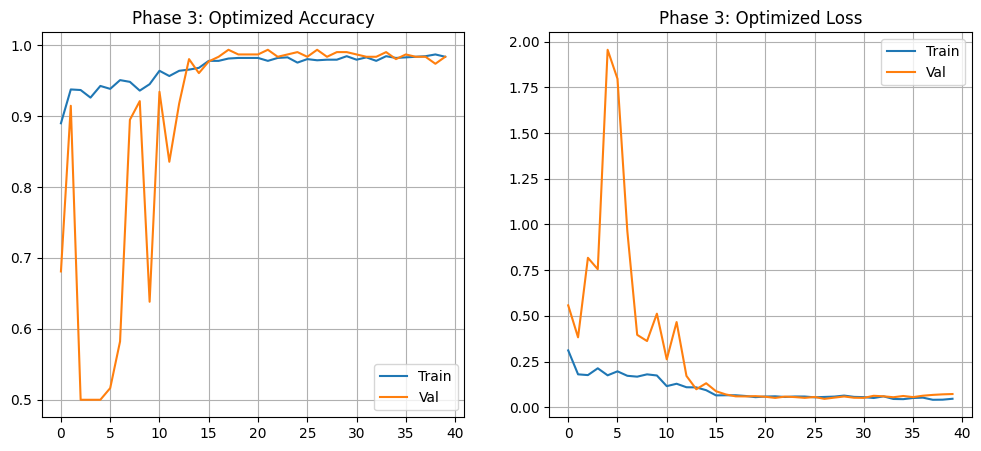


📊 Generating Final Metrics...
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 530ms/step


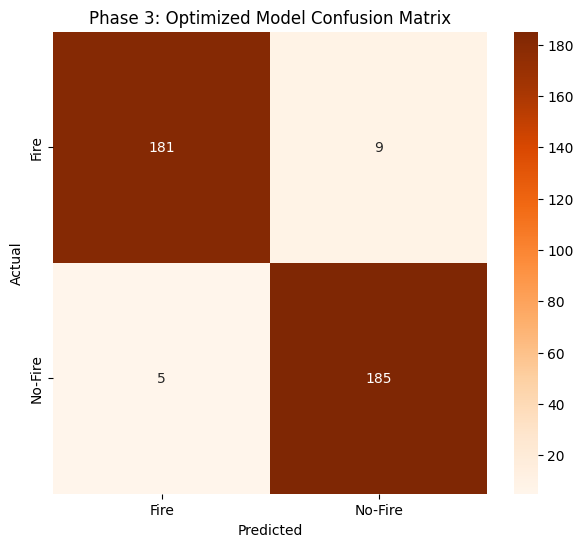


📜 Final Classification Report:
              precision    recall  f1-score   support

        Fire       0.97      0.95      0.96       190
     No-Fire       0.95      0.97      0.96       190

    accuracy                           0.96       380
   macro avg       0.96      0.96      0.96       380
weighted avg       0.96      0.96      0.96       380



In [ ]:
import os, zipfile, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, BatchNormalization, Dropout, GlobalAveragePooling2D, Dense
from sklearn.metrics import classification_report, confusion_matrix

# --- 1. EXTRACTION & PATH SETUP ---
zip_name = 'Forest Fire Dataset.zip'
if not os.path.exists(zip_name):
    print(f"❌ ERROR: '{zip_name}' not found. Please upload it to the sidebar.")
else:
    try:
        with zipfile.ZipFile(zip_name, 'r') as zip_ref:
            zip_ref.extractall('forest_fire_data')

        DATA_PATH = 'forest_fire_data/Forest Fire Dataset'
        train_dir = os.path.join(DATA_PATH, 'Training')
        test_dir = os.path.join(DATA_PATH, 'Testing')
        print("✅ Extraction Successful. Paths set.")

        # --- 2. ROBUST DATA LOGIC (Augmentation) ---
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=30,
            width_shift_range=0.2,
            horizontal_flip=True,
            brightness_range=[0.8, 1.2],
            validation_split=0.2
        )
        test_datagen = ImageDataGenerator(rescale=1./255)

        train_gen = train_datagen.flow_from_directory(train_dir, target_size=(256, 256), batch_size=32, class_mode='categorical', subset='training')
        val_gen = train_datagen.flow_from_directory(train_dir, target_size=(256, 256), batch_size=32, class_mode='categorical', subset='validation')

        test_files = [f for f in os.listdir(test_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        test_df = pd.DataFrame({'filename': test_files, 'label': ['fire' if f.lower().startswith('fire') else 'nofire' for f in test_files]})
        test_gen = test_datagen.flow_from_dataframe(test_df, directory=test_dir, x_col='filename', y_col='label', target_size=(256, 256), batch_size=32, class_mode='categorical', shuffle=False)

        # --- 3. HIGH-CAPACITY ARCHITECTURE ---
        def build_final_model():
            inputs = Input(shape=(256, 256, 3))
            x = Conv2D(64, (3, 3), padding='same', activation='relu')(inputs)
            x = BatchNormalization()(x); x = MaxPooling2D(2, 2)(x)
            x = Conv2D(128, (3, 3), padding='same', activation='relu')(x)
            x = BatchNormalization()(x); x = MaxPooling2D(2, 2)(x)
            x = Conv2D(256, (3, 3), padding='same', activation='relu')(x)
            x = BatchNormalization()(x); x = MaxPooling2D(2, 2)(x)
            x = Conv2D(128, (3, 3), padding='same', activation='relu')(x)
            x = BatchNormalization()(x); x = Dropout(0.3)(x)
            x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)
            x = GlobalAveragePooling2D()(x)
            x = Dense(256, activation='selu')(x); x = Dense(128, activation='selu')(x)
            outputs = Dense(2, activation='softmax')(x)
            return tf.keras.Model(inputs, outputs)

        model = build_final_model()
        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        lr_callback = tf.keras.callbacks.LearningRateScheduler(lambda e: 1e-3 if e<15 else (1e-4 if e<31 else 1e-5))

        # --- 4. TRAIN ---
        print("\n🚀 Starting Training of Improved Model...")
        history = model.fit(train_gen, validation_data=val_gen, epochs=40, callbacks=[lr_callback])

        # --- 5. NEW VISUALIZATIONS FOR PHASE 3 SLIDES ---
        # Accuracy/Loss Curves
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1); plt.plot(history.history['accuracy'], label='Train'); plt.plot(history.history['val_accuracy'], label='Val'); plt.title('Phase 3: Optimized Accuracy'); plt.legend(); plt.grid(True)
        plt.subplot(1, 2, 2); plt.plot(history.history['loss'], label='Train'); plt.plot(history.history['val_loss'], label='Val'); plt.title('Phase 3: Optimized Loss'); plt.legend(); plt.grid(True)
        plt.show()

        # Confusion Matrix Heatmap
        print("\n📊 Generating Final Metrics...")
        y_pred_probs = model.predict(test_gen)
        y_pred = np.argmax(y_pred_probs, axis=1)
        cm = confusion_matrix(test_gen.classes, y_pred)

        plt.figure(figsize=(7, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Fire', 'No-Fire'], yticklabels=['Fire', 'No-Fire'])
        plt.title('Phase 3: Optimized Model Confusion Matrix'); plt.ylabel('Actual'); plt.xlabel('Predicted'); plt.show()

        print("\n📜 Final Classification Report:")
        print(classification_report(test_gen.classes, y_pred, target_names=['Fire', 'No-Fire']))

    except zipfile.BadZipFile:
        print("❌ UPLOAD FAILED: The ZIP file is incomplete. Please wait for the upload circle to finish.")